In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

In [2]:
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)


In [3]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [4]:
input_dim = X_train.shape[1]

In [5]:
encoder = tf.keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=[input_dim]),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:

decoder = tf.keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=[32]),
    layers.Dense(128, activation="relu"),
    layers.Dense(input_dim)
])


In [7]:
autoencoder = tf.keras.Sequential([encoder, decoder])
autoencoder.compile(loss="mean_squared_error", optimizer="adam")


In [8]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('output/03_06_loss_plot.png')


In [9]:
history = autoencoder.fit(X_train, X_train, epochs=20, validation_data=(X_valid, X_valid))


Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.1200 - val_loss: 0.7389
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0285 - val_loss: 6.5864
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0251 - val_loss: 13.0329
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1164 - val_loss: 0.7257
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0582 - val_loss: 0.2418
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0124 - val_loss: 0.8709
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0245 - val_loss: 8.7523
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0231 - val_loss: 3.3121
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0691 - val_loss: 0.1532
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0070 - val_loss: 1.2172
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0092 - val_loss: 4.5070
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/ste

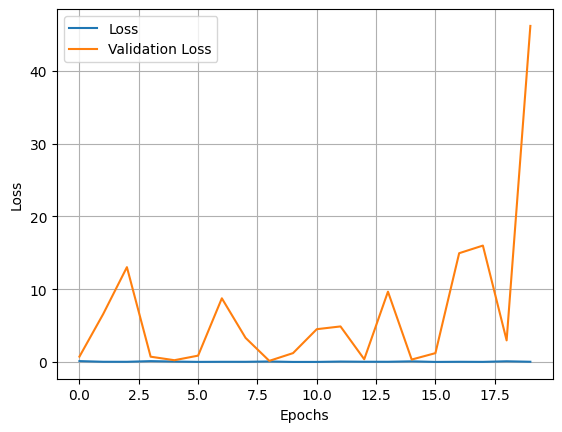

In [12]:
import os
os.makedirs('output', exist_ok=True)
plot_loss(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


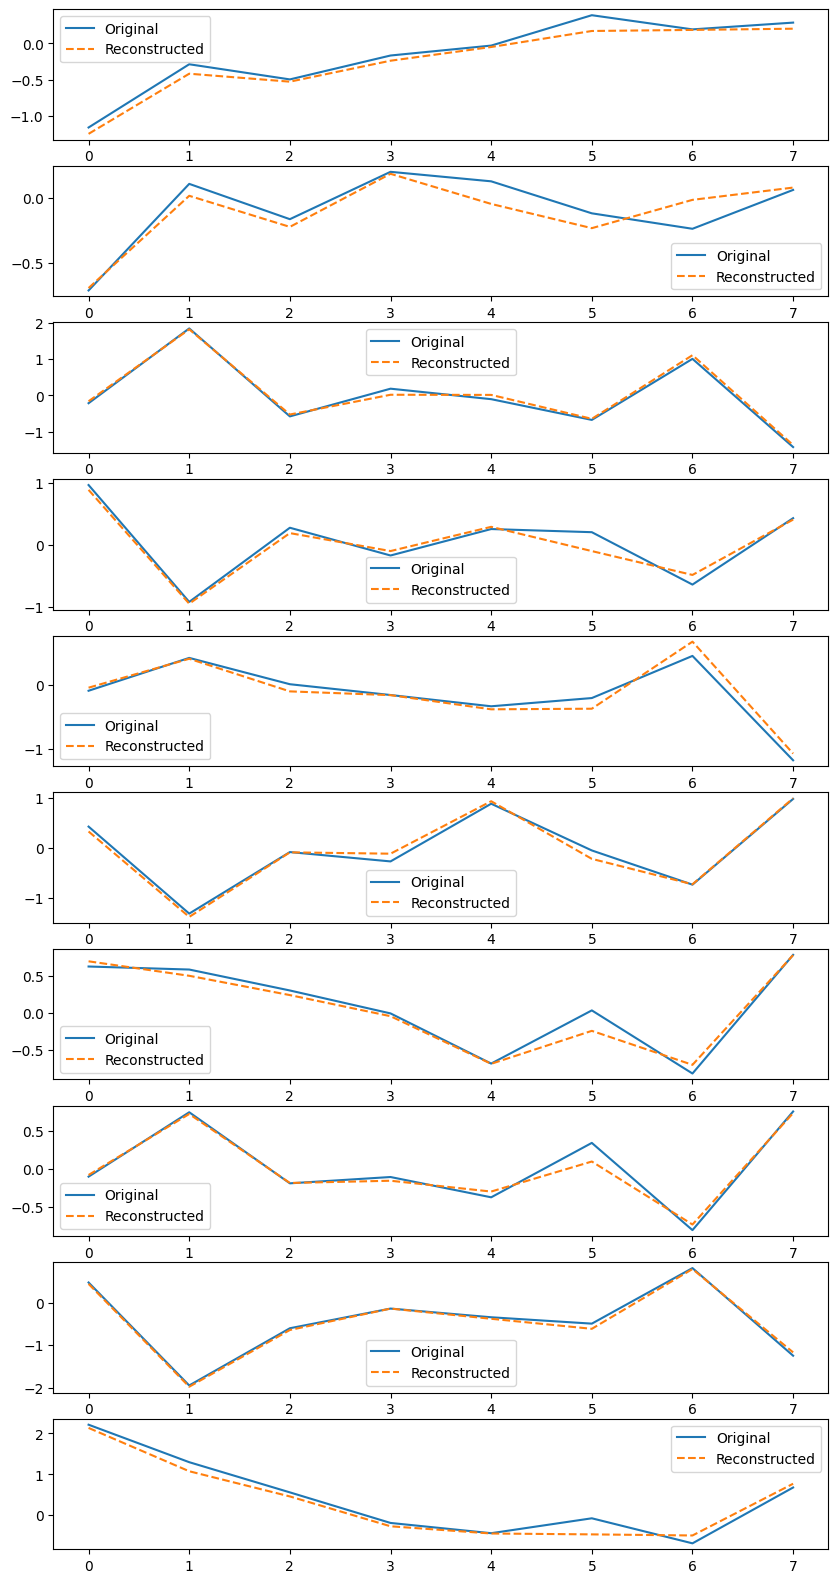

In [14]:
def plot_reconstruction(model, n=10):
    samples = X_test[:n]
    reconstructed_samples = model.predict(samples)

    fig, axs = plt.subplots(n, 1, figsize=(10, 20))
    for i in range(n):
        axs[i].plot(samples[i], label="Original")
        axs[i].plot(reconstructed_samples[i], label="Reconstructed", linestyle='--')
        axs[i].legend()
    fig.savefig('output/03_06_reconstruction_plot.png')

import os
os.makedirs('output', exist_ok=True)
plot_reconstruction(autoencoder)